In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.special import expit, logit

In [7]:
# Function to generate wave data
def wave_data(samples, n_classes, wave_type='sine'):
    # Create an empty array to hold the dataset
    X = np.zeros((samples, 2))  # 2 features for 2D (you can expand to more if needed)
    y = np.zeros(samples)

    # Generate wave-like data
    for i in range(samples):
        # Generate a wave with different frequencies
        x_val = i / float(samples) * 4 * np.pi  # Map sample index to a value over the range of [0, 4π] (full wave cycle)
        
        if wave_type == 'sine':
            X[i, 0] = np.sin(x_val)  # sine wave for the first feature
        elif wave_type == 'cosine':
            X[i, 0] = np.cos(x_val)  # cosine wave for the first feature
        elif wave_type == 'sine_cosine':
            X[i, 0] = np.sin(x_val)  # sine wave for the first feature
            X[i, 1] = np.cos(x_val)  # cosine wave for the second feature
        
        # Assign a label to each sample based on the wave position
        y[i] = int(x_val // (2 * np.pi) % n_classes)  # Assign label based on the wave cycle

    return X, y

# Generate wave data
n_samples = 100  # Number of samples
n_classes = 5    # Number of output classes
X, y = wave_data(n_samples, n_classes, wave_type='sine_cosine')

class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)  # Small random weights
        self.biases = np.zeros((1, n_neurons))  # Initialize biases to zero

    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs, weights, and biases
        self.output = np.dot(inputs, self.weights) + self.biases

# Create a dense layer with 2 input features (sine and cosine) and 3 output neurons
dense1 = Layer_Dense(n_inputs=2, n_neurons=3)

# Perform a forward pass of the wave data through the dense layer
dense1.forward(X)

# Calculate linear regression to get the slope and intercept
slope, intercept, _, _, _ = linregress(np.arange(len(X[:, 0])), X[:, 0])

# simulated linear line
linear_line = slope * np.arange(len(X[:, 0])) + intercept

### 1. Linear Activation Function

Formula: $f(x)=x$

Input equals the output. Typically seen in the output layer of a regression model, e.g., house prices. Not used in hidden layers, or if the network needs to learn non-linear relationships. It’s like trying to predict the curvature of a cooked piece of spaghetti (or a sine wave) with a raw piece of spaghetti.


Text(0, 0.5, 'Value')

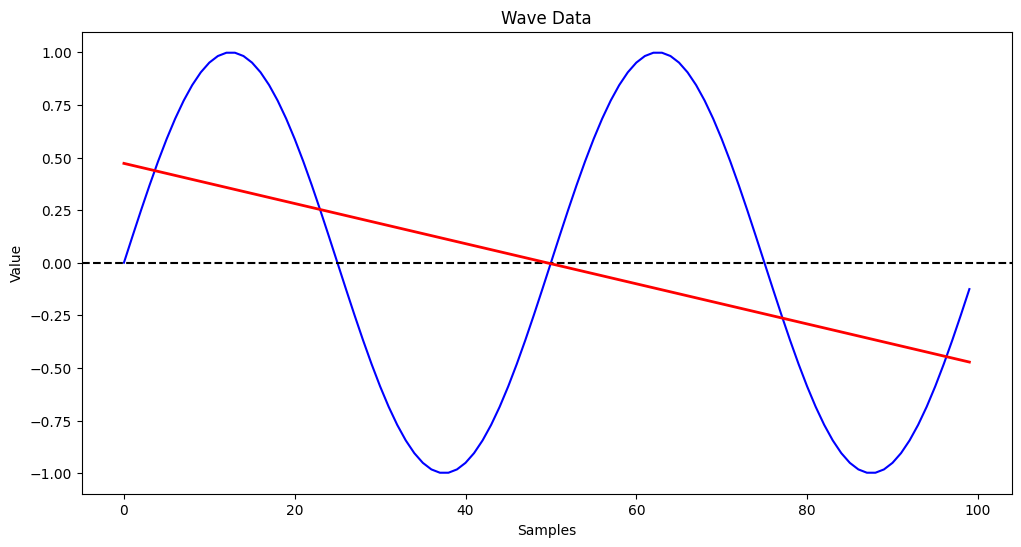

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(X[:, 0], label='Sine Wave (Feature 1)', color='blue', linewidth=1.5)
plt.title("Wave Data")
plt.xlabel('Samples')
plt.axhline(0, color='black', linestyle='--')
# Plot linear regression line
plt.plot(np.arange(len(X[:, 0])), linear_line, label='Simulated Linear Fit', color='red', linestyle='-', linewidth=2)
plt.ylabel('Value');

### 2. Sigmoid Activation Function

Formula: $f(x)= \frac{1}{1+e^{-x}}$

The Sigmoid takes all possible input values and squishes the output between 0 and 1. Handy for binary classification problems. It was the OG in the hidden layers of a network until the ReLU showed up. The negative of this function is the ‘vanishing gradient problem’ i.e,. gradients used for updating the weights become extremely small as the back-propagation happens through the layers. The derivative of the Sigmoid function will never be greater than 0.25. And those small updates slow down the neural networks ability to learn.

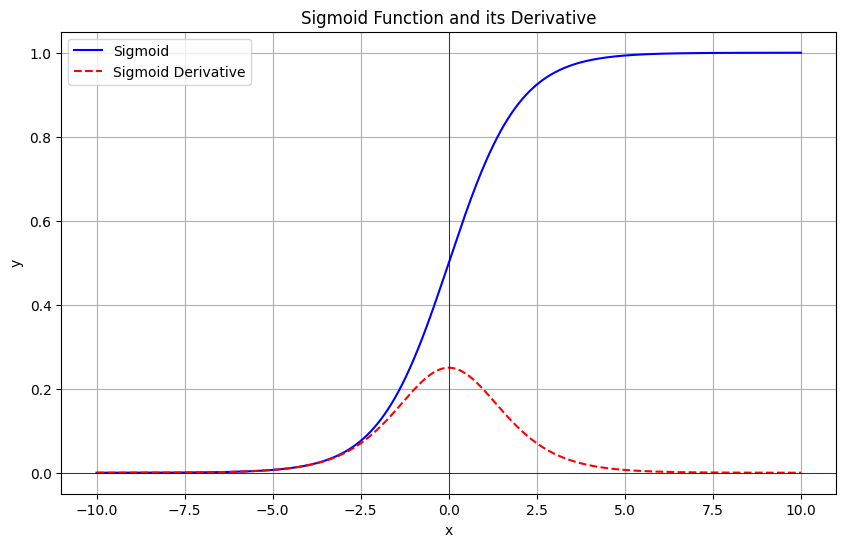

In [3]:
# Define the sigmoid function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Generate x values
x = np.linspace(-10, 10, 400)
y_sigmoid = sigmoid(x)
y_derivative = sigmoid_derivative(x)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.plot(x, y_derivative, label='Sigmoid Derivative', color='red', linestyle='--')
plt.title('Sigmoid Function and its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

### 3. Rectified Linear Activation Function (ReLU)

Formula: $f(x)=max(0,x)$

Most commonly used function in hidden layers. There are modifications to this e.g., Leaky ReLU and ELU (Eponential Linear Unit), which try to fix the issues that ReLU has (nothing is perfect), but I won’t be covering those here. This function takes any number below zero and flattens it to zero, or raises it to zero, depending on how you look at it. \
**Forward Pass:** \
    • Positive numbers are unchanged. \
    • Any number zero or below deactivates the neuron \
$y=\begin{Bmatrix}
x & x>0 \\
0 & x\le 0
\end{Bmatrix}$

It has both linearity and non-linearity combined. 

**Backward Pass:** \
    • The derivative of ReLU will be either 1 for positive outputs or 0 outputs less than 0. \
$f\acute{}=\begin{Bmatrix}
1 & \text{if x} > 0 \\
0 & \text{if x} <  0
\end{Bmatrix}$

Which acts exactly like the output of a Step Activation Function. to be clear, the ReLU is not a step activation, but functions like one in back-propagation. \
The downside, and there’s always a downside, is that the neuron can stop learning if it’s output is consistently zero. It’s called the ‘dying ReLU’ problem. Another possible negative for ReLU is that it is non-zero centered, because its output is always positive and not balance between outputs -1 and +1 like the *tanh* function it could lead to some gradients being biased. But it does solve the vanishing gradient problem since all positive outputs have a constant gradient which increases the neural networks efficiency/ speed. 

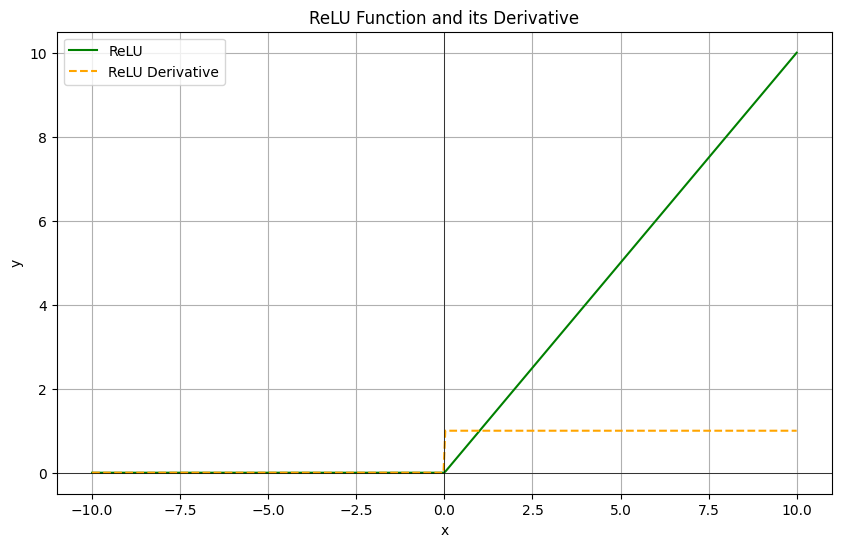

In [4]:
# Define ReLU function and its derivative
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Compute values
y_relu = relu(x)
y_relu_derivative = relu_derivative(x)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_relu, label='ReLU', color='green')
plt.plot(x, y_relu_derivative, label='ReLU Derivative', color='orange', linestyle='--')
plt.title('ReLU Function and its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

### 4. Softmax

Formula: $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$

On the surface softmax is relatively easy to understand. The question is how far down the rabbit hole do you want to go? 

The numerator is the current output of one result, out of many, which is the exponent of Euler's number (2.71828…), then normalize by dividing by the sum of all exponentials of each possibility. 

Most commonly used as the final output of a neural network, particularly in classification problems, where it produces an output between 0 and 1. It’s a multi-class classification probability and all classes will add up to 1. 

Softmax (somehow) reminds me of Forest Gump’s quote about life, chocolates, and not knowing what you’re going to get. True, but if you get a box of See’s candies with that little graphic showing you which chocolates are which your probability of getting one with a caramel interior (awesome!) vs. one with a coconut interior (disgusting!) improves vs choosing blindly. While your probability improves, your confidence level may not be very high, as with the softmax function the probabilities are dependent on the initialization and weights used. Change those and the probabilities change too. If you want to go down the rabbit hole further, here are some links:

The SoftMax Derivative, Step-by-Step!!! https://www.youtube.com/watch?v=M59JElEPgIg \
The Sigmoid Function Clearly Explained https://www.youtube.com/watch?v=TPqr8t919YM \
Krish Naik, https://www.youtube.com/@krishnaik06 \
Why do we use "e" in the Sigmoid? https://www.youtube.com/watch?v=1GqYpmLjTRQ

Resources:

*Neural Networks from Scratch in Python*, Harrison Kinsley & Daniel Kukiela \
StatQuest with Josh Starmer, https://www.youtube.com/@statquest \
Krish Naik, https://www.youtube.com/@krishnaik06 \
The SoftMax Derivative, Step-by-Step!!! https://www.youtube.com/watch?v=M59JElEPgIg \
The Sigmoid Function Clearly Explained https://www.youtube.com/watch?v=TPqr8t919YM \
Why do we use "e" in the Sigmoid? https://www.youtube.com/watch?v=1GqYpmLjTRQ